In [4]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import cartopy.crs as ccrs
import cmocean
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from matplotlib.patches import Rectangle
from datetime import datetime 
import dask

In [5]:
from OceanDataStore import OceanDataCatalog

In [6]:
catalog = OceanDataCatalog(catalog_name="noc-model-stac")

In [7]:
catalog.available_collections

['noc-rapid-evolution', 'noc-npd-jra55', 'noc-npd-era5']

In [8]:
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1m
              Title: eORCA1 ERA5v1 NPD T1m Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics monthly mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2024-12-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d
              Title: eORCA025 ERA5v1 NPD T1y_3d Icechunk repository
              Description: Icechunk repository containing eORCA025 ERA5v1 

In [6]:
catalog.available_items

['noc-npd-era5/npd-eorca1-era5v1/gn/T1y',
 'noc-npd-era5/npd-eorca1-era5v1/gn/T1m',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T1m_3d',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T5d_3d',
 'noc-npd-era5/npd-eorca12-era5v1/gn/T1y_3d',
 'noc-npd-era5/npd-eorca12-era5v1/gn/T1m_3d']

In [9]:
catalog.Items[3]

<Item id=noc-npd-era5/npd-eorca025-era5v1/gn/T1m_3d>

In [10]:
ds1 = catalog.open_dataset(id=catalog.Items[3].id,
                          start_datetime='1976-01',
                          end_datetime='2024-12', 
                          bbox = (-85.0, 0.0, 0.0, 80.0))

In [13]:
## Seperating Monthly Data 

january = []
february = []
march = []
april = []
may = []
june = []
july = []
august = []
september = []
october = []
november = []
december = []

for year in range (1976, 2025):
    january.append(f'{year}-01-15')
    february.append(f'{year}-02-15')
    march.append(f'{year}-03-15')
    april.append(f'{year}-04-15')
    may.append(f'{year}-05-15')
    june.append(f'{year}-06-15')
    july.append(f'{year}-07-15')
    august.append(f'{year}-08-15')
    september.append(f'{year}-09-15')
    october.append(f'{year}-10-15')
    november.append(f'{year}-11-15')
    december.append(f'{year}-12-15')

january_data = ds1['tos_con'].sel(time_counter=january, method='nearest')
january_data['time_counter'] = january_data['time_counter'].dt.year

february_data = ds1['tos_con'].sel(time_counter=february, method='nearest')
february_data['time_counter'] = february_data['time_counter'].dt.year

march_data = ds1['tos_con'].sel(time_counter=march, method='nearest')
march_data['time_counter'] = march_data['time_counter'].dt.year

april_data = ds1['tos_con'].sel(time_counter=april, method='nearest')
april_data['time_counter'] = april_data['time_counter'].dt.year

may_data = ds1['tos_con'].sel(time_counter=marches, method='nearest')
may_data['time_counter'] = march_data['time_counter'].dt.year

june_data = ds1['tos_con'].sel(time_counter=marches, method='nearest')
june_data['time_counter'] = march_data['time_counter'].dt.year

july_data = ds1['tos_con'].sel(time_counter=marches, method='nearest')
july_data['time_counter'] = march_data['time_counter'].dt.year

august_data = ds1['tos_con'].sel(time_counter=marches, method='nearest')
august_data['time_counter'] = march_data['time_counter'].dt.year

september_data = ds1['tos_con'].sel(time_counter=marches, method='nearest')
march_data['time_counter'] = march_data['time_counter'].dt.year

march_data = ds1['tos_con'].sel(time_counter=marches, method='nearest')
march_data['time_counter'] = march_data['time_counter'].dt.year
march_data = march_data.compute()

march_data = ds1['tos_con'].sel(time_counter=marches, method='nearest')
march_data['time_counter'] = march_data['time_counter'].dt.year
march_data = march_data.compute()

march_data = ds1['tos_con'].sel(time_counter=marches, method='nearest')
march_data['time_counter'] = march_data['time_counter'].dt.year
march_data = march_data.compute()

NameError: name 'marches' is not defined

In [10]:
## Seperating mo



## Calculating map of trend magnitudes 

ny, nx = min_temp.sizes['y'], min_temp.sizes['x']
trend_data = np.full((ny, nx), np.nan, dtype=np.float32)

for y_idx in range (ny):
    for x_idx in range (nx):
        point = min_temp.isel(y=y_idx, x=x_idx)
        try:
            z = np.polyfit(point['year'], point.values, 1)
            trend_data[y_idx, x_idx] = z[0]
        except:
            trend_data[y_idx, x_idx] = np.nan

trend_da = xr.DataArray(data = trend_data, dims=["y", "x"], 
        coords={ "y": min_temp['y'],
        "x": min_temp['x'],
        "nav_lat": (("y", "x"), min_temp['nav_lat'].values),
        "nav_lon": (("y", "x"), min_temp['nav_lon'].values)}, name="trend",
        attrs={"description": "Linear trend over time of SST Minimum"})
        

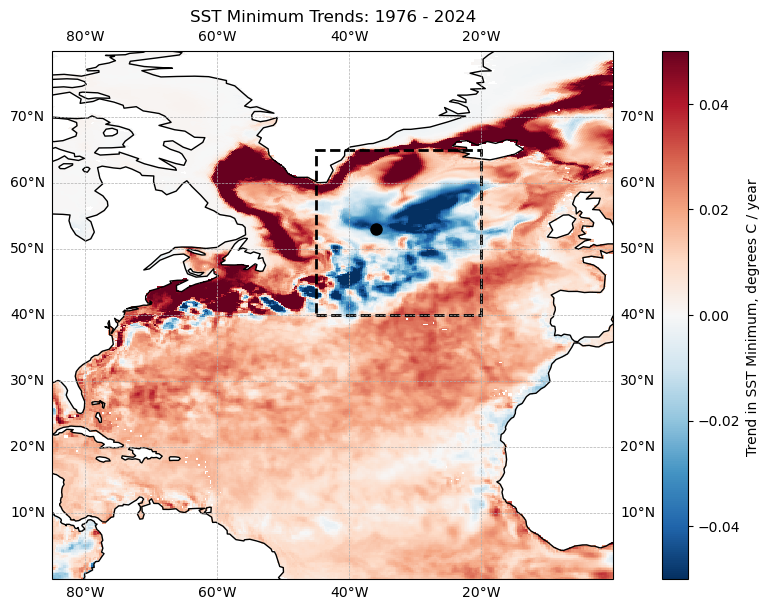

In [13]:
## Plotting Map of Trend Magnitude

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10, 6))
im = ax.pcolormesh(trend_da['nav_lon'], trend_da['nav_lat'], trend_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin= -0.05, vmax=0.05)  
ax.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax.coastlines()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', 
                facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax.add_patch(box)
ax.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax, label='Trend in SST Minimum, degrees C / year ')
plt.tight_layout()
title = ax.set_title('SST Minimum Trends: 1976 - 2024')